Primera Entrega

Puntos:

1. Para cada base de datos presenta sus dimensiones y las primeras 5 líneas.

2. Identifica y elimina los datos ausentes.

3. Presenta los tipos de datos de cada atributo de cada base de datos.

4. Presenta el resumen estadístico de cada uno de los atributos de cada base de datos.

5. Presenta la distribución de clases de cada base de datos.

6. Presenta la correlación entre atributos de cada base de datos.

7. Presenta el histograma de los atributos de cada base de datos.

8. Genera la gráfica de densidad para la distribución de los atributos de cada base de datos.

9. Genera la gráfica de cajas y bigotes para la distribución de los atributos de cada base de datos.

10. Genera la matriz de correlación de los atributos para cada una de las bases de datos.

11. Genera la matriz de dispersión de los atributos para cada base de datos.

12. Aplica escalamiento, normalización o estandarización según sea el caso a cada base de datos.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import re

In [4]:
columnas = [
    'T_xacc', 'T_yacc', 'T_zacc', 'T_xgyro', 'T_ygyro', 'T_zgyro', 'T_xmag', 'T_ymag', 'T_zmag',
    'RA_xacc', 'RA_yacc', 'RA_zacc', 'RA_xgyro', 'RA_ygyro', 'RA_zgyro', 'RA_xmag', 'RA_ymag', 'RA_zmag',
    'LA_xacc', 'LA_yacc', 'LA_zacc', 'LA_xgyro', 'LA_ygyro', 'LA_zgyro', 'LA_xmag', 'LA_ymag', 'LA_zmag',
    'RL_xacc', 'RL_yacc', 'RL_zacc', 'RL_xgyro', 'RL_ygyro', 'RL_zgyro', 'RL_xmag', 'RL_ymag', 'RL_zmag',
    'LL_xacc', 'LL_yacc', 'LL_zacc', 'LL_xgyro', 'LL_ygyro', 'LL_zgyro', 'LL_xmag', 'LL_ymag', 'LL_zmag'
]


archivos = glob.glob("DataSets/DAILYSPORTS/data/a*/p*/s*.txt")

lista_dataframes = []

for ruta in archivos:
    
    # Extraer actividad y sujeto desde la ruta usando regex
    actividad = int(re.search(r'a(\d+)', ruta).group(1))
    sujeto = int(re.search(r'p(\d+)', ruta).group(1))
    
    # Leer archivo
    df_temp = pd.read_csv(
        ruta,
        sep=',',
        header=None,
        names=columnas
    )
    
    
    df_temp['Activity_ID'] = actividad
    df_temp['Subject_ID'] = sujeto
    
    lista_dataframes.append(df_temp)


df_completo = pd.concat(lista_dataframes, ignore_index=True)


(1140000, 47)


### 1. Para cada base de datos presenta sus dimensiones y las primeras 5 líneas.

In [5]:
# Dimensiones de la base de datos
df_completo.shape

(1140000, 47)

- Contamos con 19 actividades, 8 sujetos y 60 segmentos por actividad. Sabiendo que cada segmento encapsula 5 segundos de grabación a 25 Hz (generando 125 muestras por archivo), la proyección matemática dicta: 19 × 8 × 60 × 125 = 1,140,000 registros. Si nuestro .shape arroja exactamente (1,140,000, 47), comprobamos que no hubo pérdida de paquetes en el disco y que nuestra importación es 100% íntegra. Las 47 columnas corresponden a los 45 sensores físicos  más nuestras dos variables de catalogación programática (Actividad y Sujeto).

In [6]:
#Primeras 5 filas
pd.set_option('display.max_columns', None)
print(df_completo.head())

   T_xacc  T_yacc  T_zacc   T_xgyro   T_ygyro   T_zgyro   T_xmag    T_ymag  \
0  8.1305  1.0349  5.4217 -0.009461  0.001915 -0.003424 -0.78712 -0.069654   
1  8.1305  1.0202  5.3843 -0.009368  0.023485  0.001953 -0.78717 -0.068275   
2  8.1604  1.0201  5.3622  0.015046  0.014330  0.000204 -0.78664 -0.068277   
3  8.1603  1.0052  5.3770  0.006892  0.018045  0.005649 -0.78529 -0.069849   
4  8.1605  1.0275  5.3473  0.008811  0.030433 -0.005346 -0.78742 -0.068796   

    T_zmag  RA_xacc  RA_yacc  RA_zacc  RA_xgyro  RA_ygyro  RA_zgyro  RA_xmag  \
0  0.15730  0.70097   5.6829   7.9812  0.003876 -0.005213 -0.001168 -0.57285   
1  0.15890  0.71829   5.6005   7.9712  0.012862 -0.005241 -0.003029 -0.57306   
2  0.15879  0.69849   5.6612   7.9568  0.021639 -0.010421  0.011992 -0.57357   
3  0.15912  0.72799   5.6393   7.9763  0.016440  0.001875  0.002322 -0.60463   
4  0.15916  0.71572   5.6441   7.9714  0.000286 -0.003408  0.002425 -0.56864   

   RA_ymag  RA_zmag  LA_xacc  LA_yacc  LA_zacc  LA

- Lo más valioso de este primer vistazo es comprobar cómo la red de 5 sensores mapea la postura tridimensional del sujeto midiendo la distribución de la gravedad.
  - En el Torso (T), la gravedad recae fuertemente sobre los ejes X (approx 8.16) y Z (approx 5.36), lo cual indica una leve inclinación del sensor, es decir, no está perfectamente vertical.
  - Sin embargo, si miramos la Pierna Izquierda (LL), el eje Y (LL_yacc) está recibiendo casi toda la carga gravitacional (approx -9.08), mientras que el eje Z bajó a 2.62. Esta discrepancia entre las mediciones del pecho y la pierna en el mismo instante de tiempo es la prueba de la postura de estar sentado: el torso está vertical (inclinado), pero la pierna está posicionada en un ángulo diferente respecto al suelo.

### 2. Identifica y elimina los datos ausentes.

In [7]:
# Identificar datos ausentes
datos_ausentes = df_completo.isnull().sum()

# Como son 47 columnas, obtenemos las columnas con mas de 0 nulos
columnas_con_nulos = datos_ausentes[datos_ausentes > 0]

if columnas_con_nulos.empty:
    print("Cero nulos entre los datos")
else:
    print(columnas_con_nulos)

Cero nulos entre los datos


- La ausencia total de 'dropped frames' (paquetes perdidos) demuestra que el hardware de captura y el bus de datos no sufrieron interferencias ni saturación de buffer durante las grabaciones.

### 3. Presenta los tipos de datos de cada atributo de cada base de datos.

In [8]:
# Obtenemos los tipos de datos de todas las columnas
tipos_de_datos = df_completo.dtypes

print("Tipos de datos por atributo en la base de datos completa:\n")
print(tipos_de_datos)

Tipos de datos por atributo en la base de datos completa:

T_xacc         float64
T_yacc         float64
T_zacc         float64
T_xgyro        float64
T_ygyro        float64
T_zgyro        float64
T_xmag         float64
T_ymag         float64
T_zmag         float64
RA_xacc        float64
RA_yacc        float64
RA_zacc        float64
RA_xgyro       float64
RA_ygyro       float64
RA_zgyro       float64
RA_xmag        float64
RA_ymag        float64
RA_zmag        float64
LA_xacc        float64
LA_yacc        float64
LA_zacc        float64
LA_xgyro       float64
LA_ygyro       float64
LA_zgyro       float64
LA_xmag        float64
LA_ymag        float64
LA_zmag        float64
RL_xacc        float64
RL_yacc        float64
RL_zacc        float64
RL_xgyro       float64
RL_ygyro       float64
RL_zgyro       float64
RL_xmag        float64
RL_ymag        float64
RL_zmag        float64
LL_xacc        float64
LL_yacc        float64
LL_zacc        float64
LL_xgyro       float64
LL_ygyro       float6

- Al verificar los tipos de datos, confirmamos que los 45 atributos físicos fueron correctamente interpretados como float64. Procesarlos como punto flotante asegura que no perdamos precisión decimal en las micro-variaciones de fuerza gravitacional o rotación, las cuales son vitales para diferenciar actividades sutiles.

### 4. Presenta el resumen estadístico de cada uno de los atributos de cada base de datos.

In [9]:
# Quitamos los IDs temporalmente.
columnas_fisicas = df_completo.drop(columns=['Activity_ID', 'Subject_ID'])

# Generamos el reporte
resumen_estadistico = columnas_fisicas.describe()

print(resumen_estadistico)

             T_xacc        T_yacc        T_zacc       T_xgyro       T_ygyro  \
count  1.140000e+06  1.140000e+06  1.140000e+06  1.140000e+06  1.140000e+06   
mean   7.765766e+00 -8.110365e-01  2.768845e+00 -2.796308e-03  1.369504e-02   
std    5.637887e+00  2.623027e+00  3.538260e+00  7.940107e-01  6.910401e-01   
min   -9.971500e+01 -4.994100e+01 -6.266400e+01 -2.785100e+01 -2.359800e+01   
25%    6.907000e+00 -1.509500e+00  8.998450e-01 -1.628925e-01 -1.024800e-01   
50%    8.830300e+00 -3.895300e-01  2.703700e+00  4.610000e-04  1.743750e-02   
75%    9.690500e+00  4.136200e-01  4.405200e+00  1.648200e-01  1.313100e-01   
max    9.369400e+01  4.101300e+01  1.205300e+02  2.767100e+01  1.437900e+01   

            T_zgyro        T_xmag        T_ymag        T_zmag       RA_xacc  \
count  1.140000e+06  1.140000e+06  1.140000e+06  1.140000e+06  1.140000e+06   
mean  -3.311756e-03 -5.984356e-01  6.172916e-02 -2.725170e-01  4.260595e+00   
std    3.107657e-01  3.561000e-01  3.404357e-01  3.

-  Al observar los valores min y max de cada sensor (Acelerómetro, Giroscopio y Magnetómetro en sus respectivos ejes), verificamos el rango dinámico de las 5 unidades inerciales. Si encontráramos, por ejemplo, aceleraciones de 500 m/s^2 o velocidades angulares imposibles, indicarían fallas de saturación en el sensor.

### 5. Presenta la distribución de clases de cada base de datos.

In [10]:
# Conteo absoluto (¿Cuántas filas hay de cada una de las 19 actividades?)
distribucion_absoluta = df_completo['Activity_ID'].value_counts()

# Porcentaje (¿Qué parte del total es cada actividad?)
distribucion_porcentual = df_completo['Activity_ID'].value_counts(normalize=True) * 100

print("Distribución Absoluta:")
print(distribucion_absoluta.sort_index())

print("\nDistribución Porcentual:")
print(distribucion_porcentual.sort_index().round(2))

Distribución Absoluta:
Activity_ID
1     60000
2     60000
3     60000
4     60000
5     60000
6     60000
7     60000
8     60000
9     60000
10    60000
11    60000
12    60000
13    60000
14    60000
15    60000
16    60000
17    60000
18    60000
19    60000
Name: count, dtype: int64

Distribución Porcentual:
Activity_ID
1     5.26
2     5.26
3     5.26
4     5.26
5     5.26
6     5.26
7     5.26
8     5.26
9     5.26
10    5.26
11    5.26
12    5.26
13    5.26
14    5.26
15    5.26
16    5.26
17    5.26
18    5.26
19    5.26
Name: proportion, dtype: float64


- Se puede observar que nos encontramos ante un dataset perfectamente balanceado. Justificamos que para este proyecto no será necesario aplicar técnicas de mitigación de desbalanceo paramétrico. De igual manera permite utilizar la 'Precisión Global' (Accuracy) como una métrica de evaluación confiable y directa durante la fase de entrenamiento de nuestros futuros modelos, ya que no existe el riesgo de que el algoritmo genere sesgos (bias) hacia una clase dominante.

### 6. Presenta la correlación entre atributos de cada base de datos.

In [11]:
# Aislamos los datos puramente físicos
sensores_fisicos = df_completo.drop(columns=['Activity_ID', 'Subject_ID'])

sensores_fisicos.corr()

,T_xacc,T_yacc,T_zacc,T_xgyro,T_ygyro,T_zgyro,T_xmag,T_ymag,T_zmag,RA_xacc,RA_yacc,RA_zacc,RA_xgyro,RA_ygyro,RA_zgyro,RA_xmag,RA_ymag,RA_zmag,LA_xacc,LA_yacc,LA_zacc,LA_xgyro,LA_ygyro,LA_zgyro,LA_xmag,LA_ymag,LA_zmag,RL_xacc,RL_yacc,RL_zacc,RL_xgyro,RL_ygyro,RL_zgyro,RL_xmag,RL_ymag,RL_zmag,LL_xacc,LL_yacc,LL_zacc,LL_xgyro,LL_ygyro,LL_zgyro,LL_xmag,LL_ymag,LL_zmag
T_xacc,1.000000,0.053331,-0.054986,-0.026773,-0.068504,0.003169,-0.591016,-0.184529,0.151512,0.364158,0.356560,-0.081775,0.048172,0.002902,0.034178,-0.107909,-0.058686,0.028126,0.423691,-0.278485,0.160437,-0.039254,0.002250,-0.028966,-0.158758,-0.008943,-0.108220,-0.591404,-0.296134,0.112238,0.011822,0.055039,-0.010404,0.204158,0.037480,-0.176774,-0.593010,0.237472,-0.230327,-0.016636,0.005747,0.003104,0.227881,0.017940,0.171500
T_yacc,0.053331,1.000000,0.066508,-0.118179,-0.011559,-0.037669,-0.134094,-0.459650,-0.154662,-0.070860,0.194661,-0.135600,-0.047621,-0.067418,-0.086083,0.029984,-0.175711,-0.012232,0.132830,-0.135109,0.380313,-0.053387,0.047551,-0.090271,-0.100251,0.137461,-0.342759,-0.195267,0.099748,0.437114,-0.025126,0.020236,0.180639,0.215883,-0.128417,-0.298636,-0.089925,-0.068591,-0.513622,-0.020953,-0.043983,0.173188,0.126134,0.205554,0.327572
T_zacc,-0.054986,0.066508,1.000000,0.006615,-0.079397,0.011202,0.339435,-0.039694,-0.260880,-0.043565,0.048057,0.086329,0.006156,0.030106,-0.001819,-0.031478,0.057155,0.018819,-0.066451,-0.091375,0.089522,-0.007188,0.038529,-0.011817,0.090516,-0.053359,-0.007150,0.009187,0.115000,0.028030,-0.035654,0.014507,-0.014507,-0.094319,-0.104707,-0.026779,0.021090,-0.094277,-0.004225,0.026339,-0.036481,0.029245,-0.151984,0.019141,0.038411
T_xgyro,-0.026773,-0.118179,0.006615,1.000000,0.056055,-0.013212,0.002469,0.009995,-0.004401,-0.014442,-0.022482,0.027869,0.125615,0.276110,0.123547,-0.016717,-0.008861,0.004643,-0.000439,0.013758,-0.033962,0.128001,-0.221681,0.170022,0.031298,-0.007197,-0.005263,-0.031711,0.090941,-0.032702,-0.032597,-0.047049,-0.328142,0.024360,0.018661,0.008440,0.044001,0.062133,0.058402,-0.009393,0.084131,-0.309359,-0.031994,0.026415,-0.005672
T_ygyro,-0.068504,-0.011559,-0.079397,0.056055,1.000000,0.042811,0.003438,-0.003080,-0.000500,0.025752,-0.017766,-0.004896,-0.032821,0.010055,-0.016933,-0.011548,-0.004046,0.003152,0.023741,0.035546,-0.008752,0.003420,0.014398,0.020754,-0.013072,-0.002691,0.000346,0.045526,0.078795,0.005936,-0.008473,-0.092293,-0.089547,0.007776,0.011197,-0.000563,0.064044,-0.068957,0.013085,0.023890,-0.068656,0.098332,0.007754,-0.009202,0.004194
T_zgyro,0.003169,-0.037669,0.011202,-0.013212,0.042811,1.000000,-0.000512,0.025157,-0.000305,0.042525,-0.013842,0.000511,0.025966,0.139854,0.139404,0.006234,-0.002557,-0.005079,-0.022695,-0.012584,0.012074,0.043395,-0.112473,0.131239,-0.007628,-0.014057,0.024169,0.062229,-0.025721,0.002641,-0.095070,0.049216,-0.064846,-0.056266,-0.091306,-0.004496,-0.039667,-0.027985,-0.014086,-0.105944,-0.064890,-0.035586,0.052712,-0.077401,0.005503
T_xmag,-0.591016,-0.134094,0.339435,0.002469,0.003438,-0.000512,1.000000,0.236828,-0.196212,-0.148252,-0.202448,0.069973,-0.004966,0.011826,-0.010812,0.189963,0.200710,-0.006188,-0.204614,0.093666,-0.213846,0.007769,0.023868,0.005088,0.258589,-0.085092,0.250069,0.305167,0.114979,-0.202372,-0.005929,-0.021619,0.005194,-0.364458,-0.036172,0.210704,0.269361,-0.078272,0.257083,0.010094,-0.030161,-0.009005,-0.404034,-0.033786,-0.226247
T_ymag,-0.184529,-0.459650,-0.039694,0.009995,-0.003080,0.025157,0.236828,1.000000,-0.001092,0.002773,-0.148483,0.135349,0.010513,0.015550,0.023063,-0.111102,0.261836,-0.491116,-0.149106,0.121267,-0.240341,0.009903,-0.008611,0.029317,0.115893,0.300807,0.462297,0.142663,-0.039065,-0.327775,0.002790,0.012325,-0.049306,-0.136241,0.001020,0.824691,0.066671,0.028801,0.378229,-0.002521,0.006030,-0.049903,0.010640,0.019598,-0.852145
T_zmag,0.151512,-0.154662,-0.260880,-0.004401,-0.000500,-0.000305,-0.196212,-0.001092,1.000000,0.185852,-0.036213,-0.063890,0.001594,-0.014526,0.006690,-0.

- Esta matriz cruda será el insumo fundamental si en el futuro deseamos automatizar la poda de características (Feature Selection) para eliminar la multicolinealidad, programando umbrales de exclusión exactos.

### 7. Presenta el histograma de los atributos de cada base de datos.

<function matplotlib.pyplot.show(close=None, block=None)>

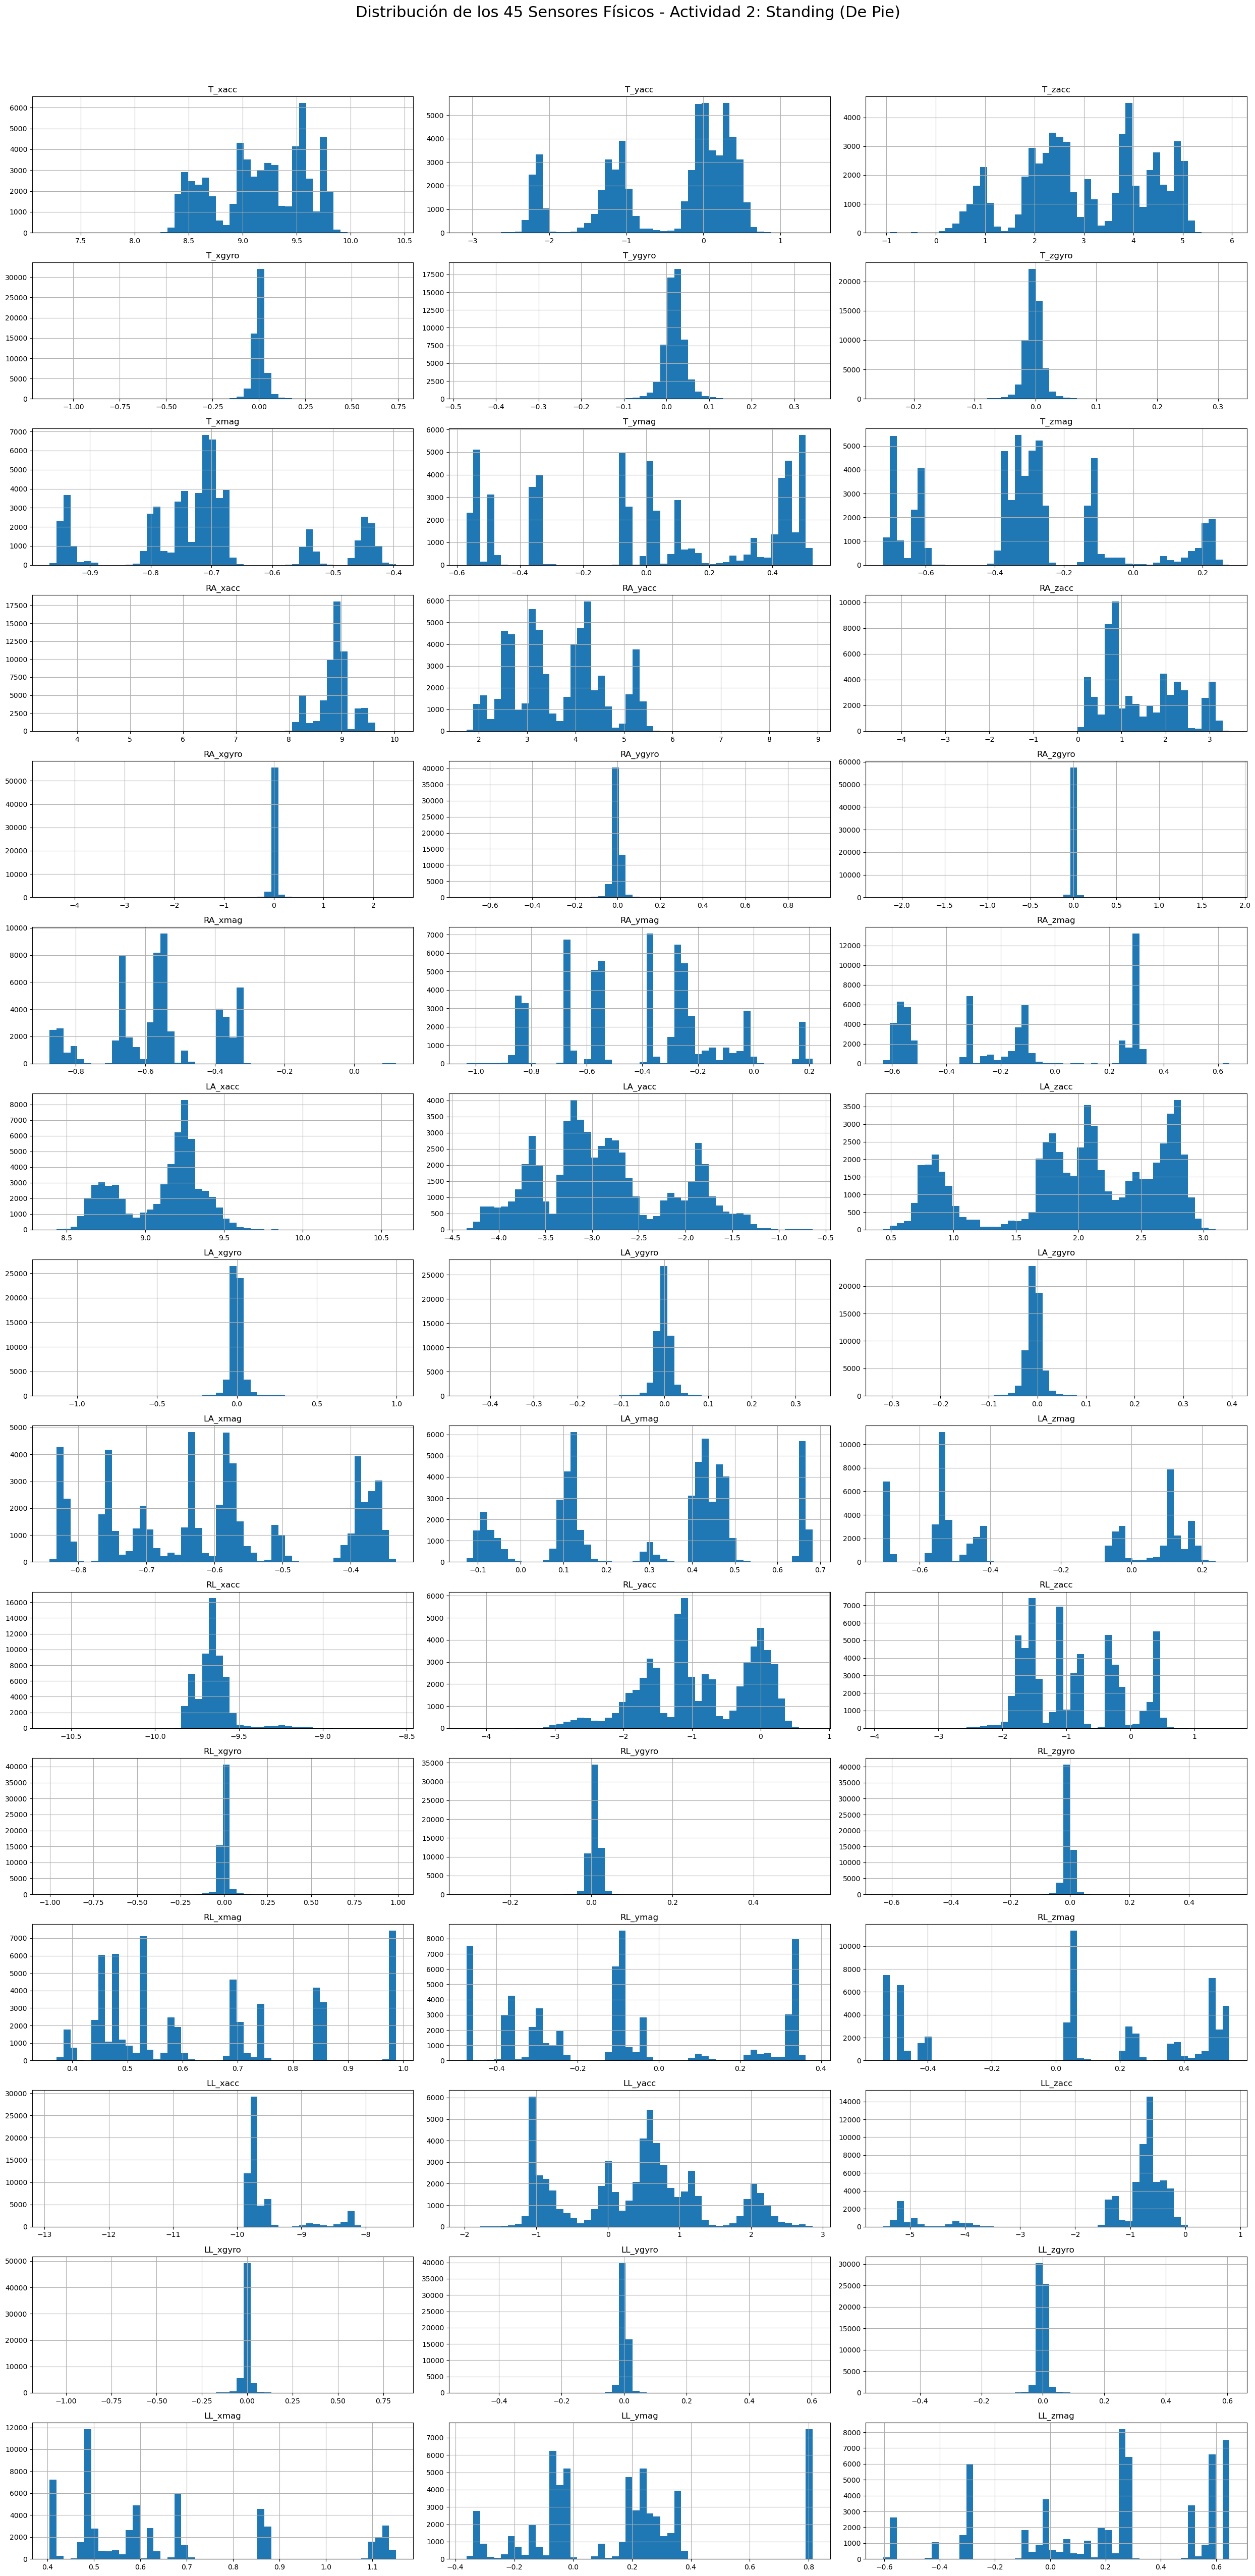

In [17]:
# Filtramos para mostrar actividad 2 (de pie)
actividad_standing = df_completo[df_completo['Activity_ID'] == 2]

# Le quitamos las etiquetas
sensores_standing = actividad_standing.drop(columns=['Activity_ID', 'Subject_ID'])

sensores_standing.hist(
    bins=50, 
    layout=(15,3),
    figsize=(25, 50), 
    color='skyblue', 
    edgecolor='white', # Bordecitos blancos para que se vea más limpio
    linewidth=0.5,
    alpha=0.8
)

plt.suptitle('Distribución de los 45 Sensores Físicos - Actividad 2: Standing (De Pie)', fontsize=22, y=1.02)
plt.tight_layout()

plt.show

 - Al analizar los histogramas condicionados de la actividad estática 'Standing' (A2), detectamos una clara dicotomía entre la respuesta giroscópica y acelerométrica:
  - Los giroscopios (_gyro) presentan distribuciones unimodales centradas en 0 rad/s, validando que la velocidad angular es nula y los sujetos efectivamente se encontraban inmóviles.
  -  Los acelerómetros (_acc) y magnetómetros (_mag), por el contrario, exhiben distribuciones fuertemente multimodales (múltiples picos separados). Dado que el acelerómetro actúa como un inclinómetro respecto a la gravedad (9.8 m/s^2), estos picos no representan movimiento dinámico, sino las distintas posturas de descanso de los 8 voluntarios.
  -  Este hallazgo nos advierte que nuestro futuro algoritmo de Machine Learning no deberá buscar un 'valor único' para definir la acción de estar de pie, sino que tendrá que aprender a englobar estas múltiples sub-posturas dentro de la misma clase utilizando límites de decisión no lineales.

### 8. Genera la gráfica de densidad para la distribución de los atributos de cada base de datos.

<function matplotlib.pyplot.show(close=None, block=None)>

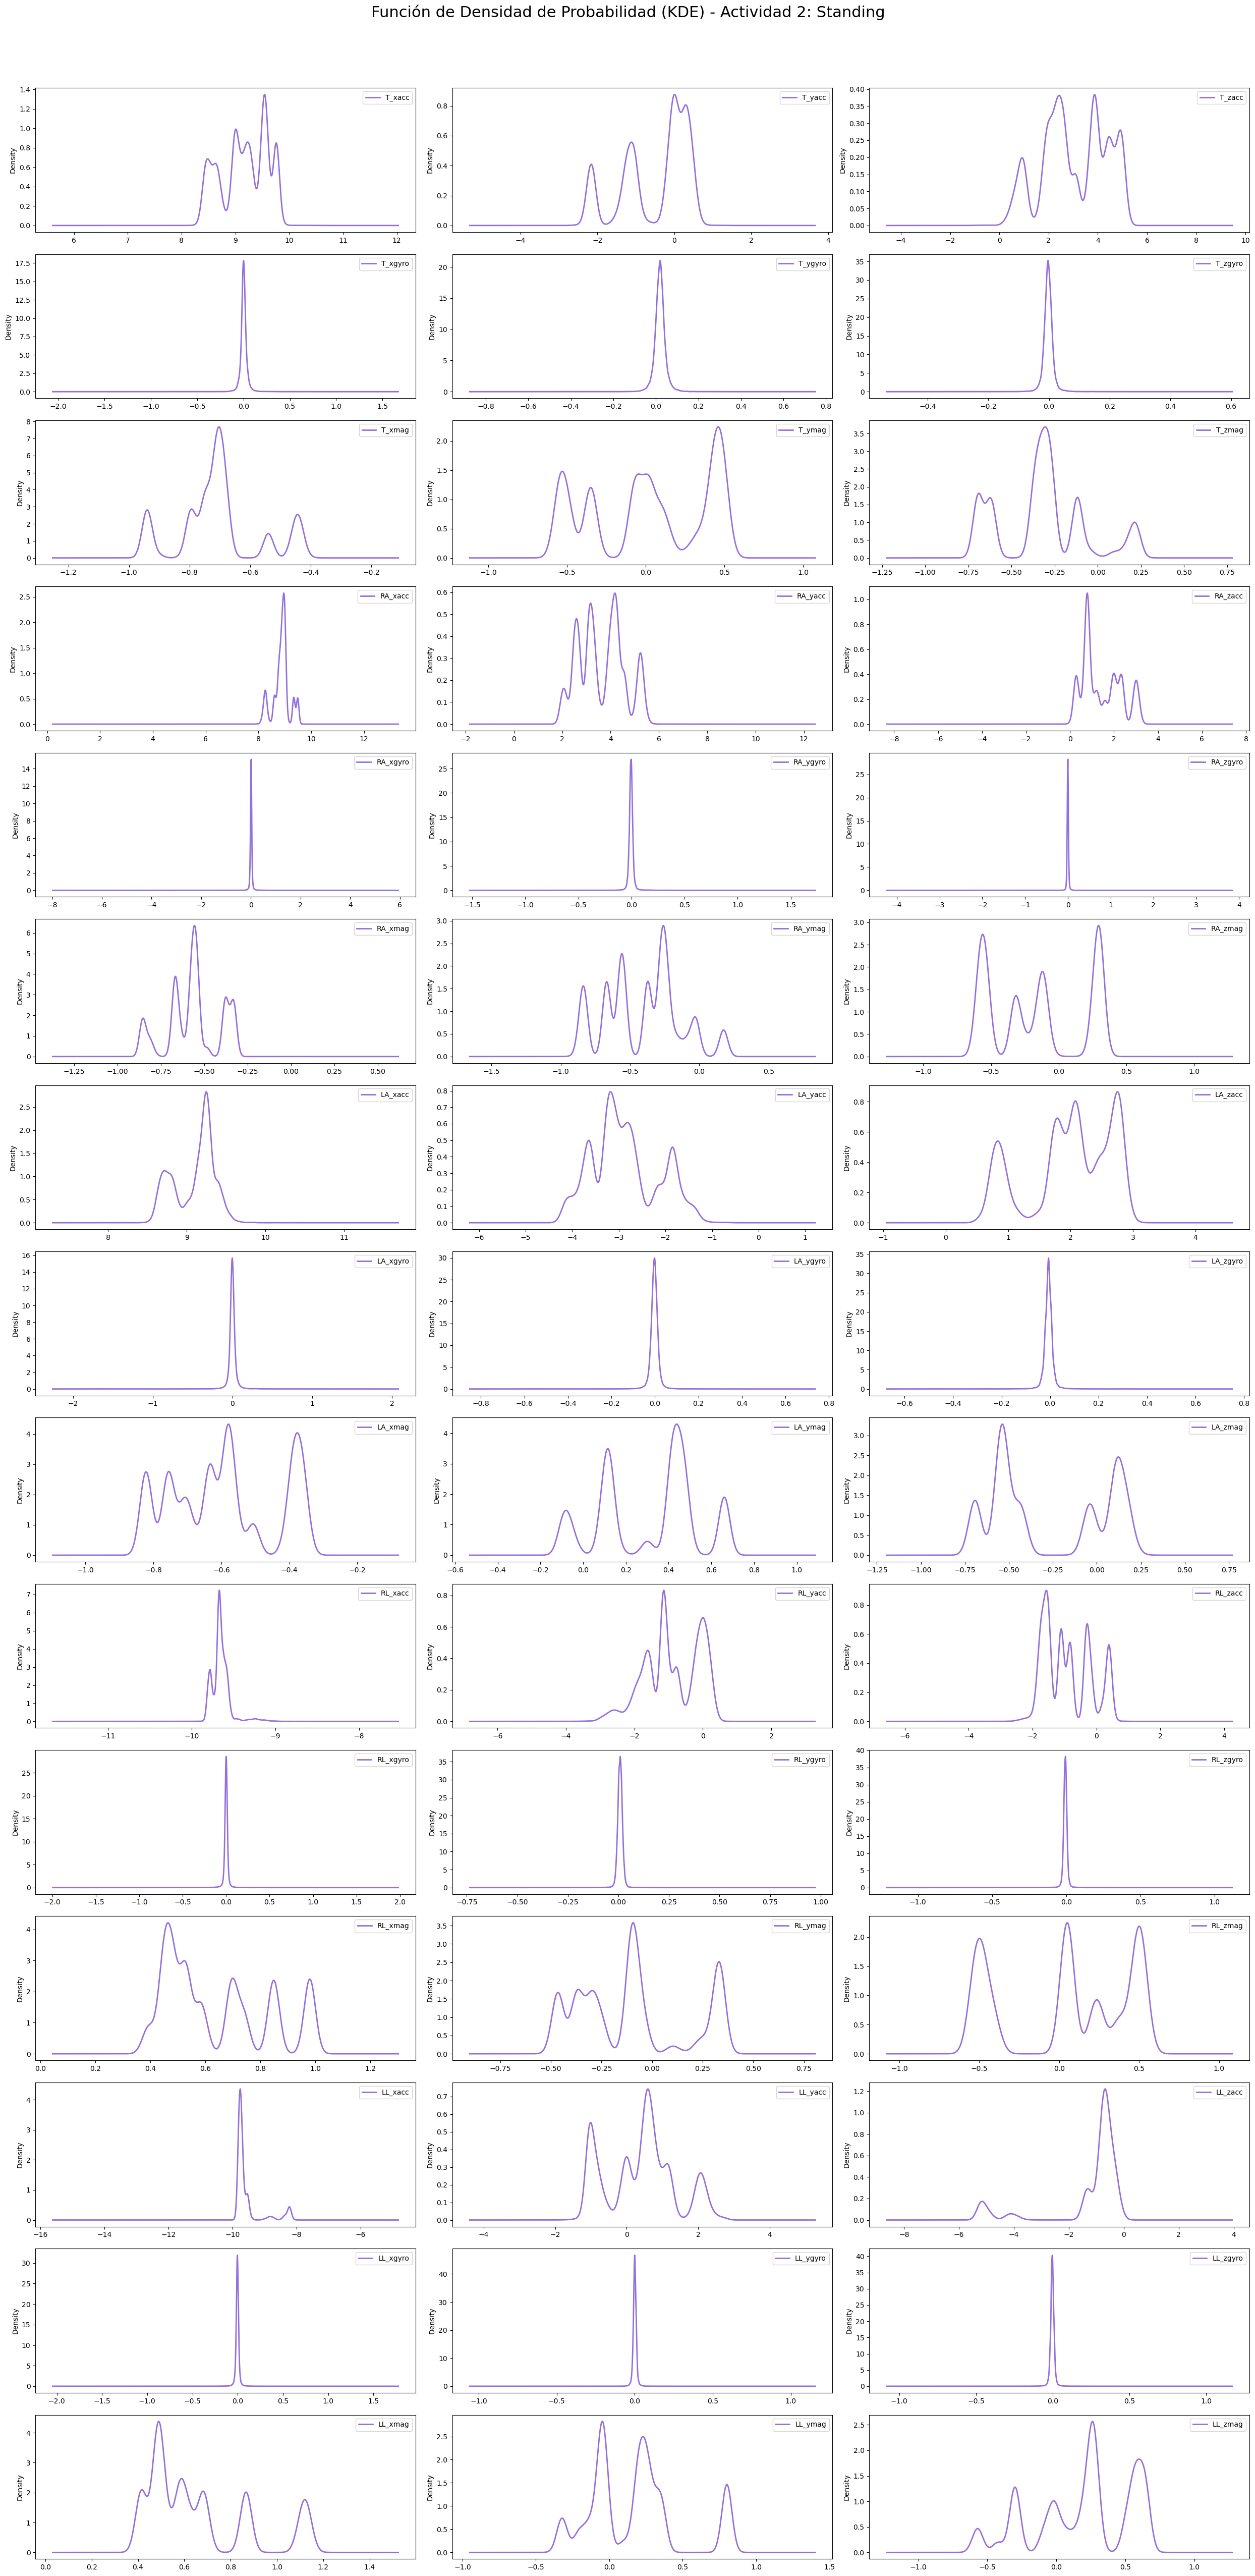

In [13]:
# Dibujamos el mosaico de densidades
sensores_standing.plot(
    kind='density', 
    subplots=True, 
    layout=(15, 3),  
    figsize=(25, 50),
    sharex=False,     
    color='mediumpurple', 
    linewidth=2
)

plt.suptitle('Función de Densidad de Probabilidad (KDE) - Actividad 2: Standing', fontsize=22, y=1.02)
plt.tight_layout()

plt.show

- Lo más valioso de esta visualización suavizada es la confirmación definitiva de la multimodalidad en los atributos espaciales (acelerómetros y magnetómetros). Al difuminar el ruido, los KDE exponen agrupaciones (clústeres) perfectas que representan las distintas micro-posturas de descanso de los 8 sujetos.

### 9. Genera la gráfica de cajas y bigotes para la distribución de los atributos de cada base de datos.

<function matplotlib.pyplot.show(close=None, block=None)>

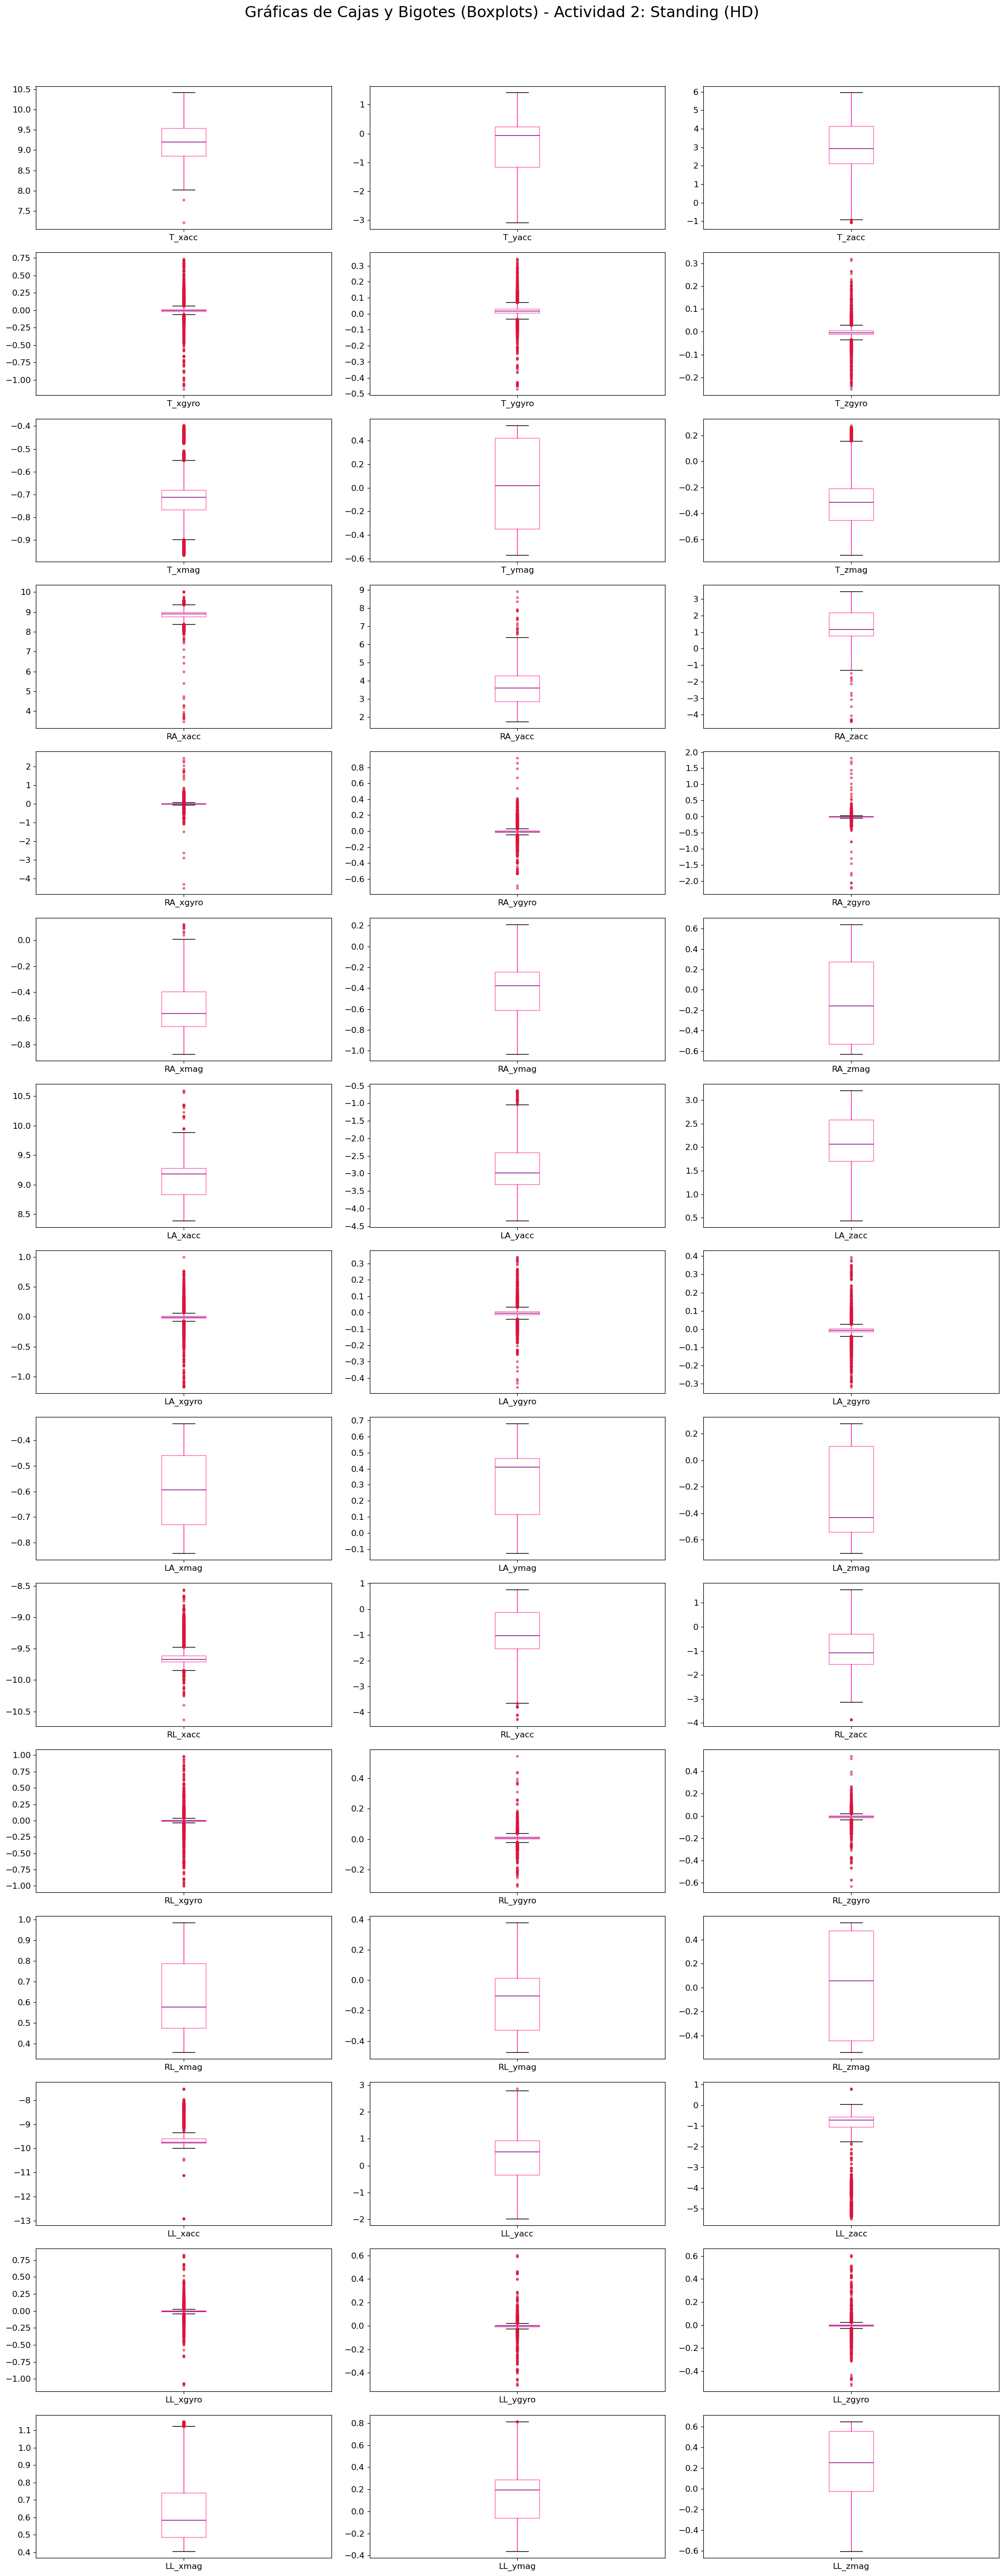

In [14]:
color_props = dict(boxes='hotpink', whiskers='deeppink', medians='purple', caps='black')
puntitos_props = dict(marker='o', markerfacecolor='crimson', markersize=4, alpha=0.6, markeredgecolor='none')

# Dibujamos el mosaico
sensores_standing.plot(
    kind='box', 
    subplots=True, 
    layout=(15, 3),  
    figsize=(20, 50), 
    color=color_props,
    flierprops=puntitos_props,
    fontsize=12      
)


plt.suptitle('Gráficas de Cajas y Bigotes (Boxplots) - Actividad 2: Standing (HD)', fontsize=22, y=1.02)
plt.tight_layout()

plt.show

- Se puede observar en los gyroscopios como nuestra caja es casi inexistente, y se presenta mas como una linea dado que el sujeto se encontraba "quieto". Sin embargo, se presentan enormes colas de valores atípicos los cuales documentan espasmos musculares, acomodos de postura, y el balanceo subconsciente (postural sway) de los 8 sujetos.
- Los valores atípicos de los acelerómetros representan a los sujetos que quizás tenían las manos en los bolsillos o los brazos cruzados, rompiendo la tendencia de la mayoría.
- La asimetría de la mediana respecto a los cuartiles (Q1 y Q3) dentro de la caja nos confirma que la distribución de la postura no es Normal (Gaussiana). Esta asimetría visual nos obliga a descartar la media aritmética como medida de tendencia central confiable para este dataset, coronando a la mediana como nuestra métrica principal.

### 10. Genera la matriz de correlación de los atributos para cada una de las bases de datos.

<function matplotlib.pyplot.show(close=None, block=None)>

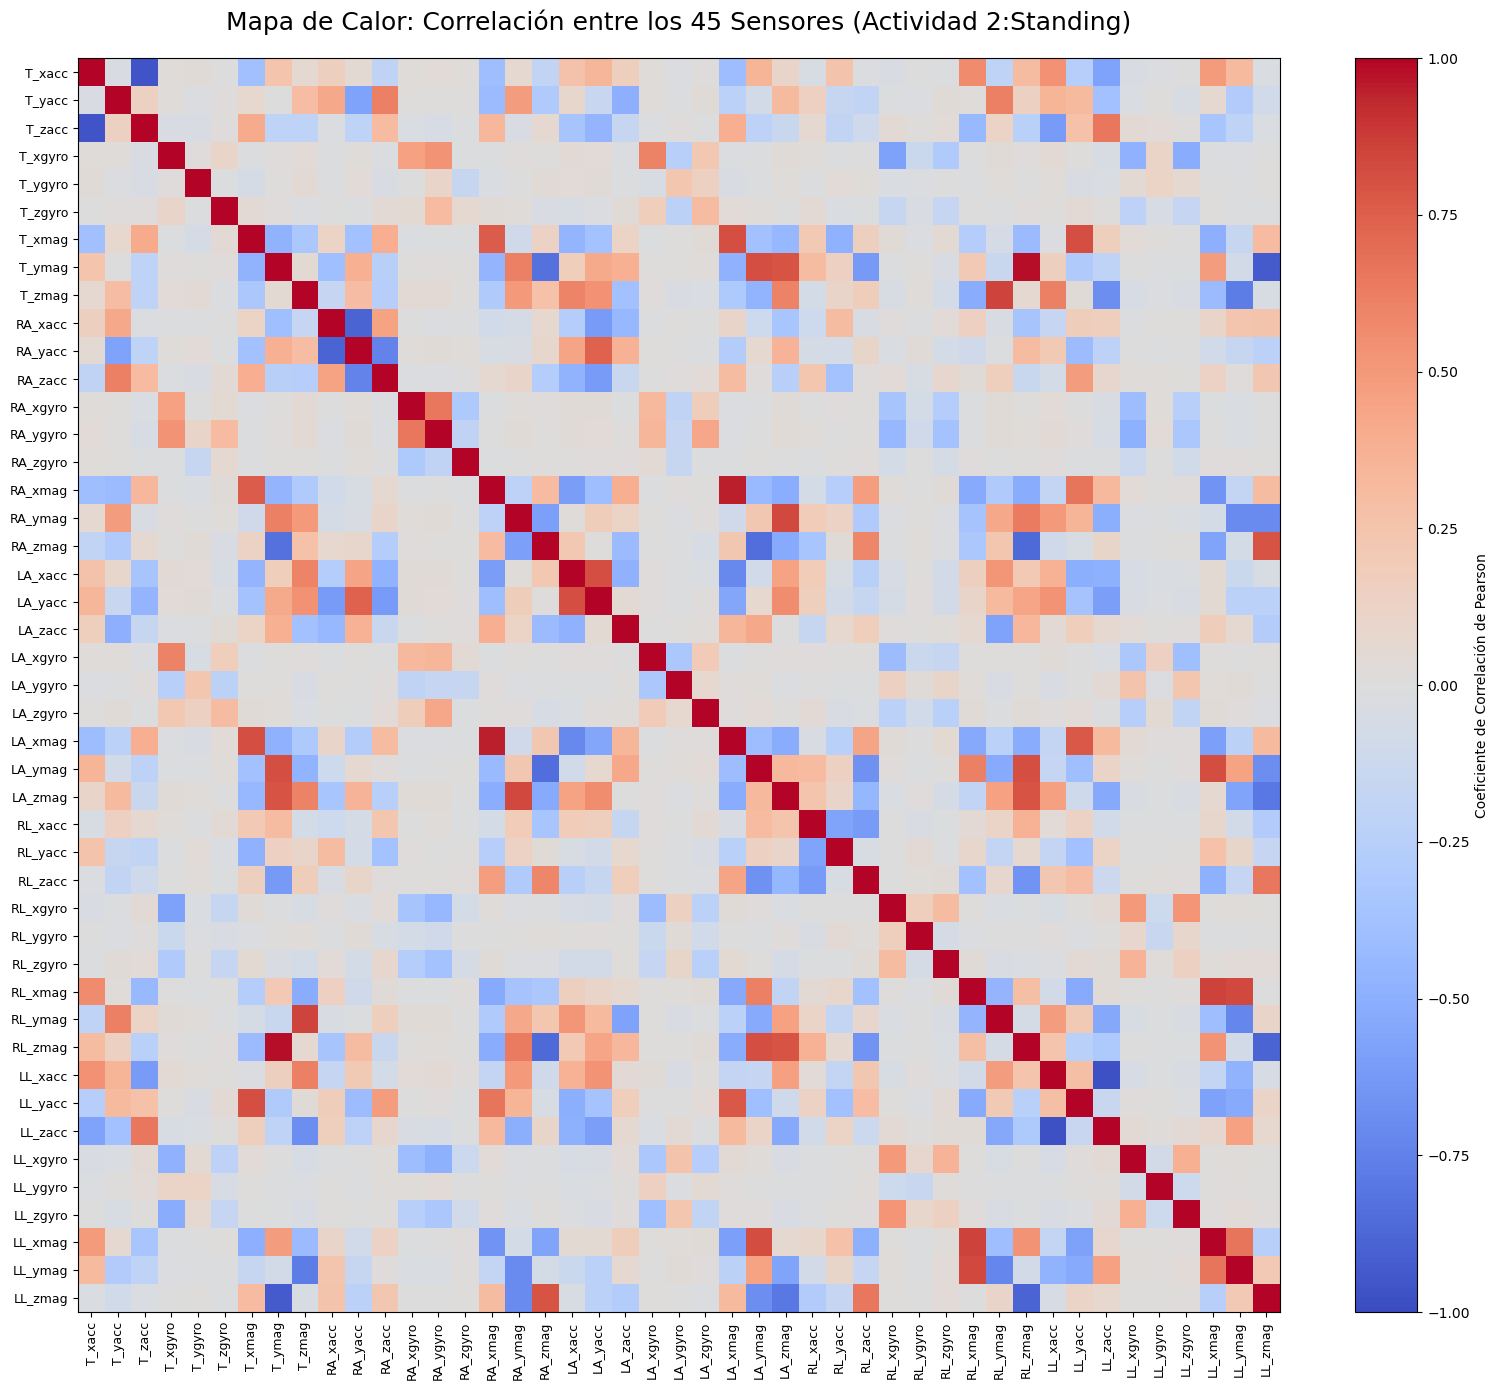

In [15]:
# Aislamos los datos puramente físicos
sensores_fisicos = df_completo.drop(columns=['Activity_ID', 'Subject_ID'])

# Calculamos la matriz de correlación de Pearson
matriz_correlacion = sensores_standing.corr()

# Dibujamos el Mapa de Calor
plt.figure(figsize=(16, 14))

# Usamos imshow para dibujar la cuadrícula, coolwarm da rojo a los +1 y azul a los -1
imagen = plt.imshow(matriz_correlacion, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')

# Agregamos la barra de colores al lado
plt.colorbar(imagen, label='Coeficiente de Correlación de Pearson')
plt.title('Mapa de Calor: Correlación entre los 45 Sensores (Actividad 2:Standing)', fontsize=18, pad=20)

# Ponemos los nombres de las 45 columnas en los bordes
posiciones = np.arange(len(sensores_fisicos.columns))
plt.xticks(posiciones, sensores_fisicos.columns, rotation=90, fontsize=9)
plt.yticks(posiciones, sensores_fisicos.columns, fontsize=9)

plt.grid(False) 
plt.tight_layout()

plt.show

- Al aislar la Actividad 2, los giroscopios pierden toda colinealidad. Físicamente, esto ocurre porque el 'postural sway' (el micro-balanceo para mantener el equilibrio) es un proceso estocástico (aleatorio) del sistema nervioso para cada extremidad.
- Las fuertes correlaciones encontradas aquí (por ejemplo, entre acelerómetros de extremidades opuestas) nos indican que el cuerpo humano actúa como una cadena cinemática cerrada al combatir la gravedad. Para nuestro futuro modelo predictivo, estos clústeres fuertemente correlacionados dentro de una misma actividad son los candidatos perfectos para ser fusionados mediante Análisis de Componentes Principales (PCA), reduciendo la dimensionalidad sin perder la 'huella dactilar' de la postura.

### 11. Genera la matriz de dispersión de los atributos para cada base de datos.

<function matplotlib.pyplot.show(close=None, block=None)>

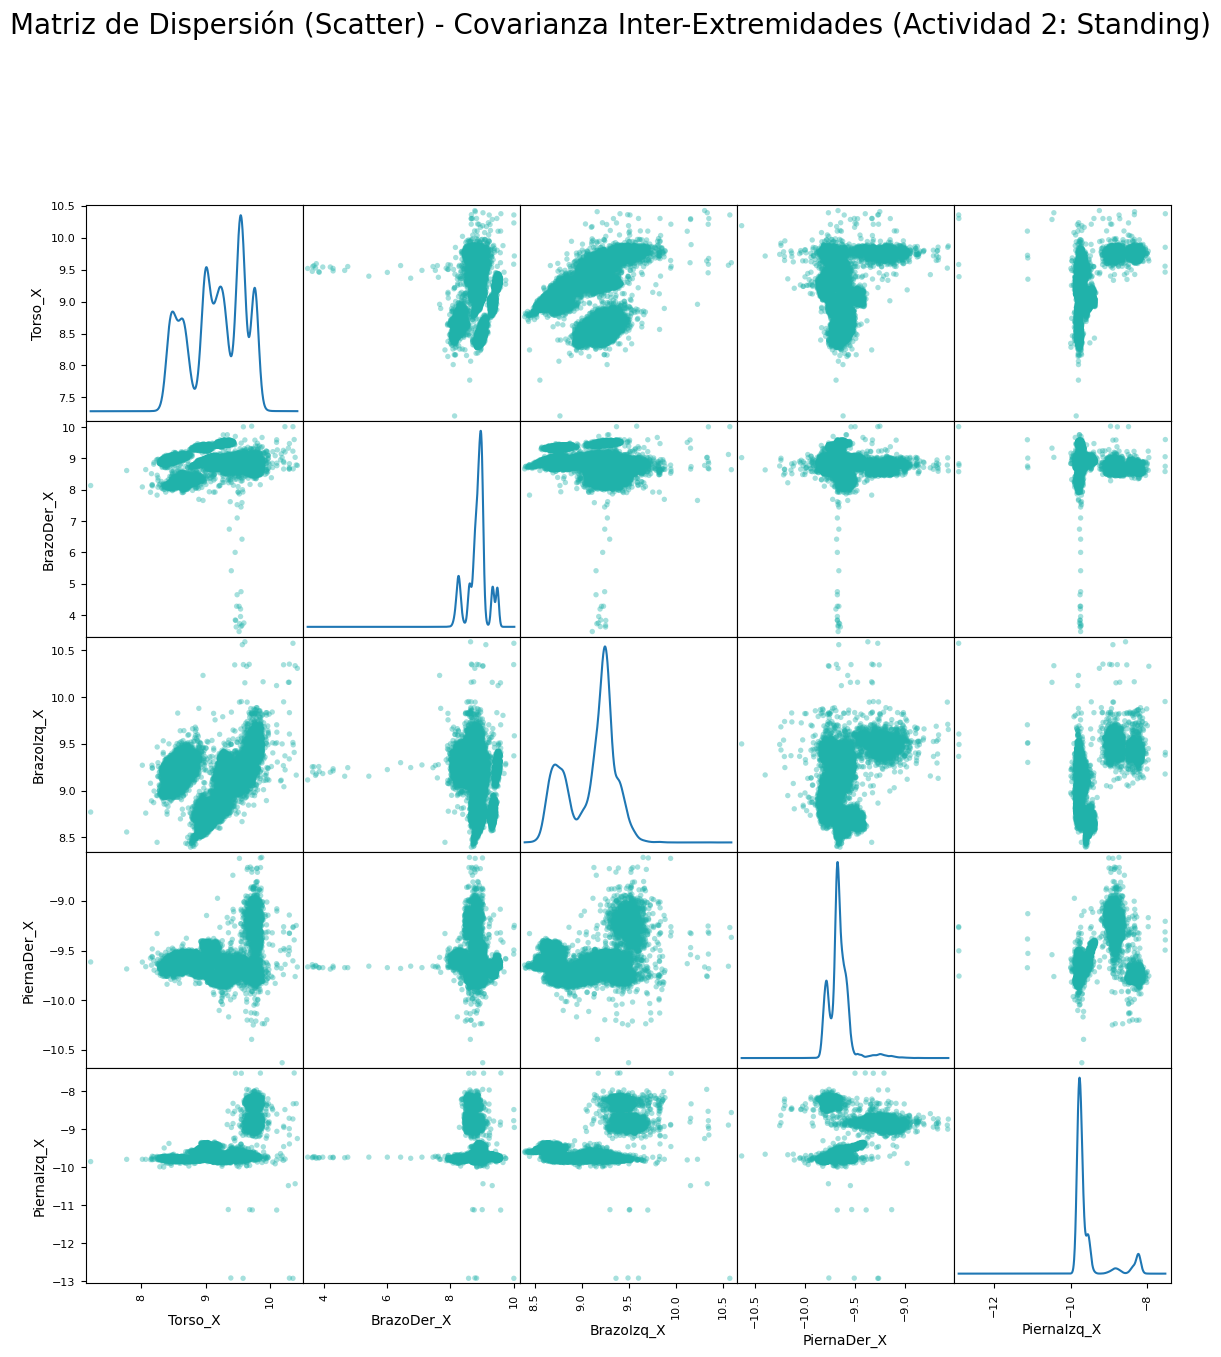

In [16]:
# Elegimos nuestros 5 sensores estratégicos (El eje X de los acelerómetros)
sensores_estrategicos = ['T_xacc', 'RA_xacc', 'LA_xacc', 'RL_xacc', 'LL_xacc']
datos_scatter = sensores_standing[sensores_estrategicos].copy()

datos_scatter.columns = ['Torso_X', 'BrazoDer_X', 'BrazoIzq_X', 'PiernaDer_X', 'PiernaIzq_X']

pd.plotting.scatter_matrix(
    datos_scatter, 
    alpha=0.4,           
    figsize=(14, 14),   
    diagonal='kde',      
    color='lightseagreen', 
    marker='o',          
    s=15                 
)

plt.suptitle('Matriz de Dispersión (Scatter) - Covarianza Inter-Extremidades (Actividad 2: Standing)', fontsize=20, y=1.02)

plt.show

- Mientras que la correlación global entre las extremidades puede resultar estadísticamente baja, la matriz de dispersión nos revela visualmente la presencia de densos 'clústeres'.
- Estas nubes confirman que la postura de reposo no es un punto único en el espacio matemático, sino una colección de micro-estados. Para un algoritmo de Machine Learning, esta visualización es invaluable, ya que demuestra que, aunque los datos no sean separables por modelos lineales simples, algoritmos basados en densidad o distancia (como SVM o KNN) tendrán excelentes fronteras de decisión gracias a los espacios vacíos entre las nubes.